## 회귀

머신러닝 회귀에서 중요한 것: 최적의 회귀 계수를 찾아내는 것임.
선형 회귀: 실제 값가 예측값의 차이를 최소화 하는 직선형 회귀선을 최적화 하는 방식.
선형 회귀도 규제 방법에 따라 종류가 나뉨. 대표적인게 로직스틱 회귀임


### 단순 선형 회귀

독립변수도 하나, 종속 변수도 하나인 선형 회귀임.
독립 변수가 1개인 단순 선형 회귀에서는 기울기와 절편을 회귀 계수로 지칭함. 그리고 회귀 모델을 1차 함수로 모델링 했다면
실제 주택 가격은 1차 함수 값에서 실제 값만큼의 오류 값을 뺀 또는 더한 값이 됩니다. 
실제 값과 회귀 모델의 차이에 따른 오류를 잔차 라고 부름.
최적의 회귀 모델을 만든다는 것은 잔차의 합이 최소가 되는 모델을 만든다는 의미임.

RSS방식은 오류의 합을 구할 때 각각 제곱을 하고 더하는 방식.
회귀에서 이 RSS는 손실이며 비용함수라고 함. 또 다른 말로는 손실 함수 라고도 함.


### 경사 하강법

RSS를 최소화 하는 방법을 직관적으로 제공하는 방식임.

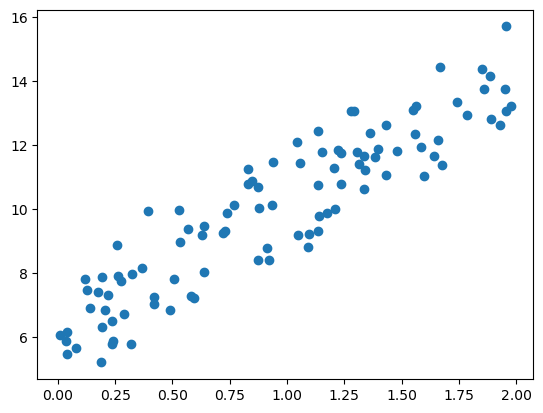

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
#y=4x+6을 근사, 임의의 값은 노이즈를 위해 만듦
X=2*np.random.rand(100,1) #0 부터 1까지 중 하나로 값이 나옴, 모든 값이 비슷한 확률로 나옴.
y=6+4*X+np.random.randn(100,1) #평균이 0이 되게끔 하고 분산이 1이 되게끔 만듦.

plt.scatter(X,y)



아래는 비용 함수 실제 y값과 예측된 y값을 인자로 받아서 계산해 반환함.

In [11]:
def get_cost(y, y_pred): #비용함수 구하는거임.
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost    

경사하강법 함수 구현하기

In [15]:
#w1, w0를 업데이트할 w1_update, w2_update를 반환
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
  N = len(y)
  #먼저 w1_update, w0_update를 각각 w1,w0의 shape와 동일한 크기를 가진 0 값으로 초기화
  w1_update = np.zeros_like(w1) #w1, w0도 배열임,
  w0_update = np.zeros_like(w0)
  #예측 배열 계산하고 예측과 실제 값의 차이 계산
  y_pred = np.dot(X,w1.T) + w0 #dot은 내적임. T는 transpose한다는 뜻이.
  diff = y-y_pred

  #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
  w0_factors = np.ones((N,1))

  #w1,w0을 업데이트할 w1_update, w0_update 계산
  w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
  w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))
  #얘네는 직접 바꾸는게 아니라 얼마만큼 바꿔야 하는지를 알려줌.  
  return w1_update, w0_update

In [ ]:
위에서 만든 함수 써서 iter만큼 학습시킴.

In [13]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트
def gradient_descent_steps(X,y, iters=10000):
  #w0,w1을 모두 0으로 초기화
  w0 = np.zeros((1,1))
  w1 = np.zeros((1,1))

  #인자로 주어진 iters만큼 반복적으로 get_weight_updates() 호출해 w0,w1 업데이트 수행
  for ind in range(iters):
    w1_update, w0_update = get_weight_updates(w1,w0,X,y,learning_rate=0.01)
    w1 = w1 - w1_update
    w0 = w0 - w0_update

  return w1, w0

In [16]:
def get_cost(y, y_pred):
  N = len(y)
  cost = np.sum(np.square(y-y_pred))/N
  return cost

w1,w0 = gradient_descent_steps(X,y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0]*X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))  #예측 오류 비용

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


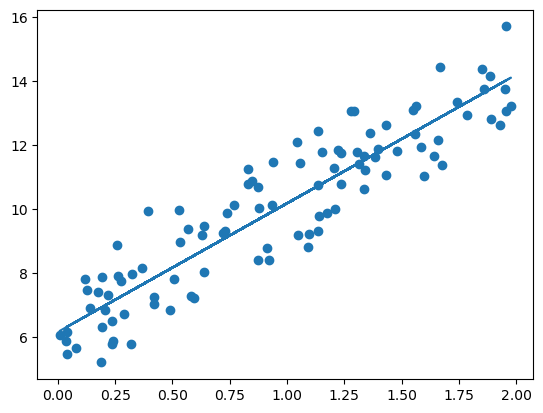

In [18]:
plt.scatter(X,y)
plt.plot(X, y_pred)

하지만 경사하강법은 시간이 많이 걸린다는 문제가 있음 -> 실무에서는 확률 경사하강법이나 미니 경사하강법 을 사용함

In [20]:
#확률 경사하강법
def stochastic_gradient_descent_steps(X,y, batch_size=10, iters=1000):
  w0 = np.zeros((1,1))
  w1 = np.zeros((1,1))

  for ind in range(iters):
    np.random.seed(ind)
    #전체 X,y 데이터에서 랜덤하게 batch_size만큼 추출해 sample_X, sample_y로 저장
    stochastic_random_index = np.random.permutation(X.shape[0])
    sample_X = X[stochastic_random_index[0:batch_size]]
    sample_y = y[stochastic_random_index[0:batch_size]]
    #랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
    w1_update, w0_update = get_weight_updates(w1,w0,sample_X, sample_y, learning_rate=0.01)
    w1 = w1 - w1_update
    w0 = w0 - w0_update
      
  return w1,w0

In [21]:
w1,w0 = stochastic_gradient_descent_steps(X,y,iters=1000)
print("w1:", round(w1[0,0],3), "w0:",round(w0[0,0],3))
y_pred = w1[0,0]*X + w0
print('Stochiastric Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1: 4.028 w0: 6.156
Stochiastric Gradient Descent Total Cost:0.9937


### 사이킷 런

linearRegression 클래스
classsklearn.linearmodel.LinearRegrssion(fit_intercept, normalize, copy_x, n_jobs)
입력 파라미터 fit_intercept: 디폴트는 true이고 intercept(절편)을 계산할 것인지 말지를 지정함. 만일 False로 지정하면 intercept 사용 안하고 0으로 지정.
nomarlize: 디폴트는 FAlse로 false인 경우에는 이 파라미터 무시됨. 참이면은 회귀 수행하기 전에 입력 데이터 세트를 정규화함.
RSS 회귀 계수 계산은 입력 피처의 독립성에 큰 영향을 받음. 따라서 상관관계 높은 피처는 중요한 피처만 남기고 없애야함.

회귀 평가 지표
회귀 성능 지표는 MAE(차이 절댓값 합), MSE(실제 값과 예측 값의 차이 제곱 평균), RMSE(MSE에다가 루트 씌운 것), R^2(분산 기반) 등이 있음.

In [36]:
#보스톤 데이터가 윤리 문제로 사용 불가능 하다 하여 캘리포니아 데이터로 대체

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
import warnings

warnings.filterwarnings('ignore')

# california 데이터셋 로드
california = fetch_california_housing()

# DataFrame 변환
caliDF = pd.DataFrame(california.data, columns=california.feature_names)

# target 추가
caliDF['PRICE'] = california.target #target이 원래는 y값인데 컬럼으로 넣어준다고 생각.

print('California 데이터셋 크기 :', caliDF.shape)
caliDF.head()

California 데이터셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


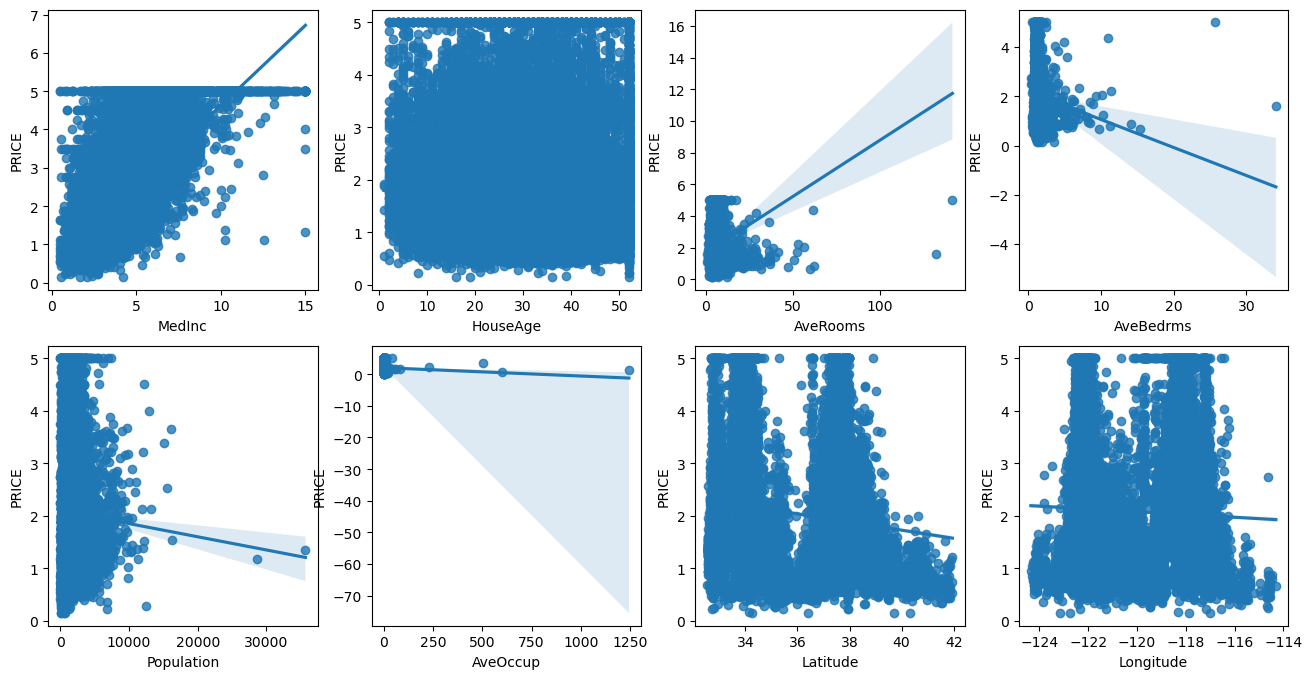

In [33]:
# 2개 행, 4개 열 subplot이용함.
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2) #axs는 4*2 개로 구성.

lm_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms','Population', 'AveOccup', 'Latitude', 'Longitude']

for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 산점도 + 선형회귀선
    sns.regplot(x=feature, y='PRICE', data=caliDF, ax=axs[row][col])

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target=caliDF['PRICE']
X_data=caliDF.drop(['PRICE'], axis=1, inplace=False)
X_train, X_test,y_train, y_test=train_test_split(X_data, y_target, test_size=0.3, random_state=156)

lr=LinearRegression()
lr.fit(X_train, y_train)
y_preds=lr.predict(X_test)

mse=mean_squared_error(y_test,y_preds)
rmse=np.sqrt(mse)

print('MSE:{0:.3f}, RMSE:{1:.3F}'.format(mse, rmse))
print('Variance score: {0:3f}'.format(r2_score(y_test, y_preds)))

MSE:0.543, RMSE:0.737
Variance score: 0.595225


In [48]:
# 절편이랑 회귀계수 확인하기
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: -37.23905305294164
회귀 계수값: [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [49]:
#coef는 회귀계수 값만 가지고 있어서, 이를 피쳐별 회귀계수 값으로 매핑하고 출력
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False) #내림차순


AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

aveBedrms가 양의 값으로 회귀 계수가 큼. -> 양의 측으로 많은 영향을 미침

In [50]:

from sklearn.model_selection import cross_val_score

y_target = caliDF['PRICE']
X_data = caliDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5) #neg_mean_squared_error는 원래 값의 음수 반환.
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))


 5 folds 의 개별 Negative MSE scores:  [-0.48 -0.62 -0.65 -0.54 -0.49]
 5 folds 의 개별 RMSE scores :  [0.7  0.79 0.8  0.74 0.7 ]
 5 folds 의 평균 RMSE : 0.746 


## 다중회귀 -직선보다 곡선이 더 예측 잘해서 차수 높이는건데 너무 높이면 과적합 문제가 생김


In [51]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [52]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


In [54]:
# 선형회귀에 적용
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)
#그러니깐 결론적으로 차수를 높이게 되었지만 높였음에도 기존과 동일한 결괏값을 도출하는 식을 만들기 위한 과정임.
#“차수를 높이는 것은 더 복잡한 관계를 표현하기 위한 것이며, 이 예제에서는 실제 데이터가 다항식 구조라서 동일한 결과를 복원할 수 있다.”

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


In [55]:
# 사이킷런의 pipeline 객체를 이용해서 피쳐변환과 선형 회귀 한번에 하기.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))
#이러면 이 위 셀에 해당하는 코드랑 같은 결과를 도출

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


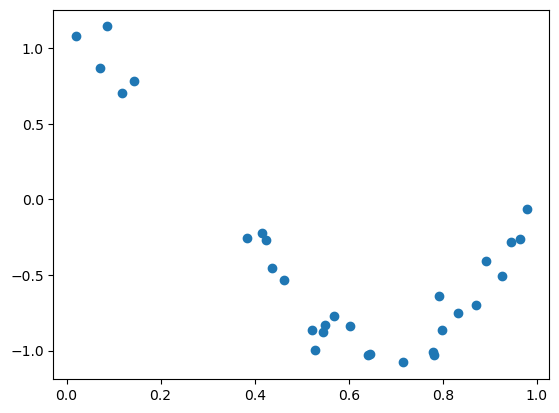

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1
plt.scatter(X, y)


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986834 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231656 입니다.

Degree 15 회귀 계수는 [-2.98294000e+03  1.03899610e+05 -1.87416521e+06  2.03716656e+07
 -1.44873596e+08  7.09316905e+08 -2.47066334e+09  6.24562439e+09
 -1.15676772e+10  1.56895297e+10 -1.54006385e+10  1.06457519e+10
 -4.91378737e+09  1.35919988e+09 -1.70381227e+08] 입니다.
Degree 15 MSE 는 182544649.2483548 입니다.


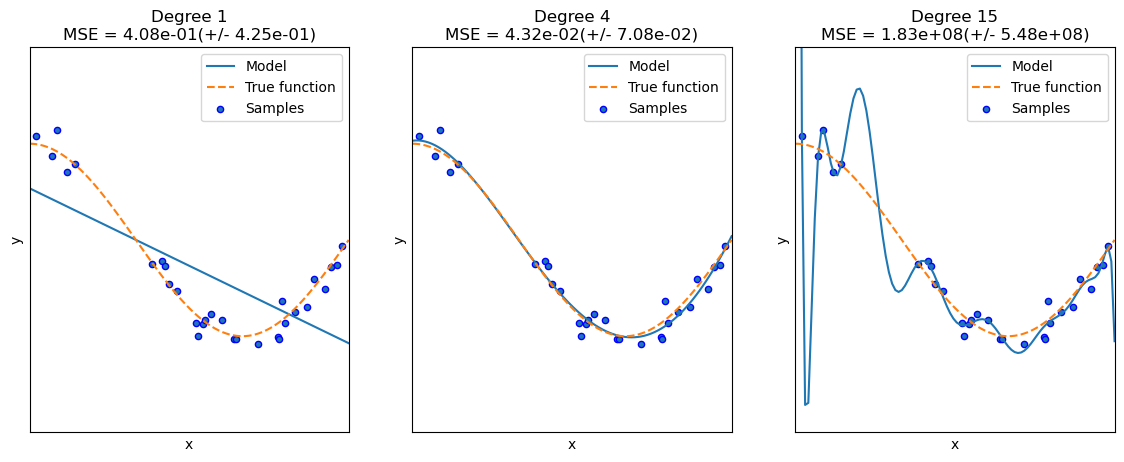

In [58]:
#이제 위에꺼를 다항식 차수를 각각 1,4,15로 변경한 뒤 예측 결과 확인하는 코드.

plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

실선은 다항회귀의 예측 곡선임, 점섬으로 표시된거는 실제 데이터 세트
1차원은 너무 단순한 느낌이 있음. 4차원은 실제 데이터 세트와 윳가한 모습을 보임. 잡은은 예측 못했지만 가장 비교적 잘 반영함.
15차원은 너무 큰 오류값. 잡음값까지 너무 지나치게 반영해버림.

## 편향 분산 트레이드 오프

1차원 같은 모델을 매우 단순화된 모델로 고편향성을 가졌다고 말함. 반대로 15차원 같은 것들은 매우 복잡한 모델이 되어서 고분산성을 가지고 있다고 말함